In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [2]:
providers = pd.read_csv("cleaned_data/providers_clean.csv")
receivers = pd.read_csv("cleaned_data/receivers_clean.csv")
food = pd.read_csv("cleaned_data/food_clean.csv")
claims = pd.read_csv("cleaned_data/claims_clean.csv")

In [4]:
providers.head()
receivers.head()
food.head()
claims.head()
providers.info()
receivers.info()
food.info()
claims.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Provider_ID  1000 non-null   int64 
 1   Name         1000 non-null   object
 2   Type         1000 non-null   object
 3   Address      1000 non-null   object
 4   City         1000 non-null   object
 5   Contact      1000 non-null   object
dtypes: int64(1), object(5)
memory usage: 47.0+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Receiver_ID  1000 non-null   int64 
 1   Name         1000 non-null   object
 2   Type         1000 non-null   object
 3   City         1000 non-null   object
 4   Contact      1000 non-null   object
dtypes: int64(1), object(4)
memory usage: 39.2+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999


In [5]:
providers.isnull().sum()

Provider_ID    0
Name           0
Type           0
Address        0
City           0
Contact        0
dtype: int64

In [6]:
receivers.isnull().sum()

Receiver_ID    0
Name           0
Type           0
City           0
Contact        0
dtype: int64

In [7]:
food.isnull().sum()

Food_ID          0
Food_Name        0
Quantity         0
Expiry_Date      0
Provider_ID      0
Provider_Type    0
Location         0
Food_Type        0
Meal_Type        0
dtype: int64

In [8]:
claims.isnull().sum()

Claim_ID       0
Food_ID        0
Receiver_ID    0
Status         0
Timestamp      0
dtype: int64

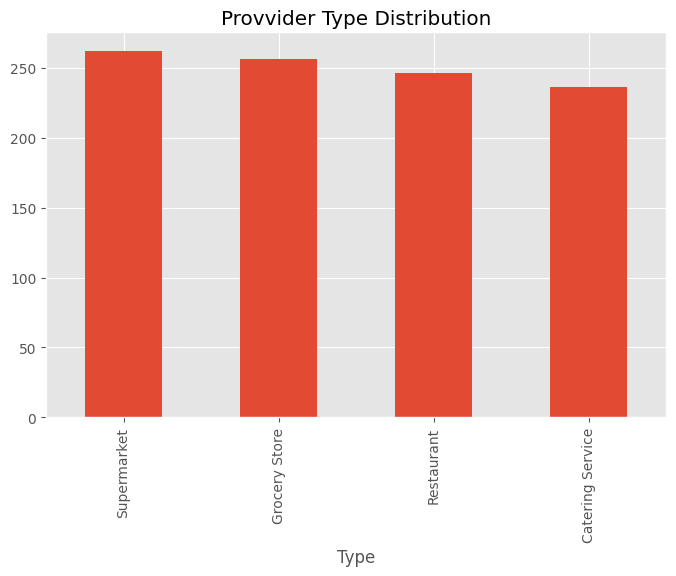

In [9]:
plt.figure( figsize=(8,5))
providers['Type'].value_counts().plot(
    kind='bar'
)
plt.title("Provvider Type Distribution")
plt.show()

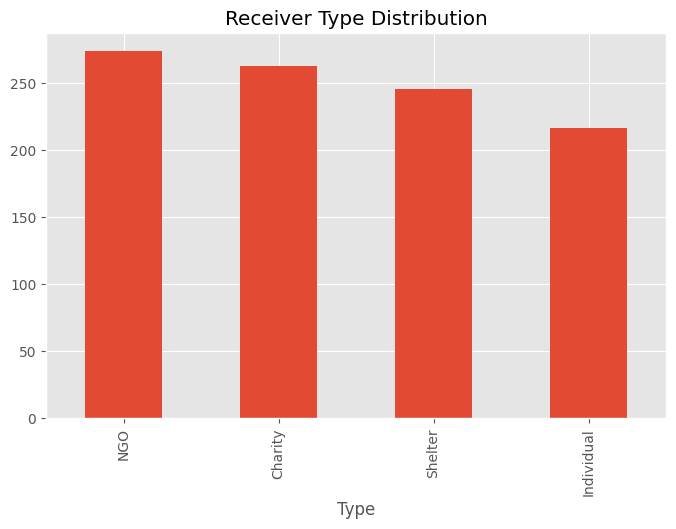

In [10]:
plt.figure( figsize=(8,5))
receivers['Type'].value_counts().plot(
    kind='bar'
)
plt.title("Receiver Type Distribution")
plt.show()

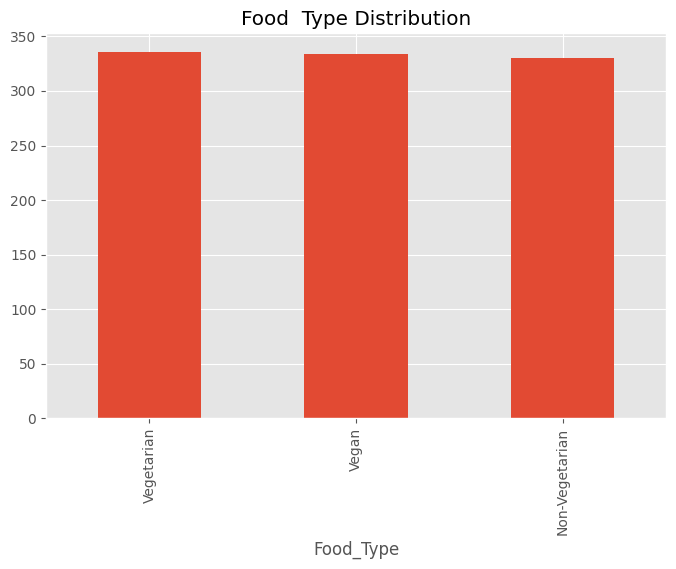

In [12]:
plt.figure( figsize=(8,5))
food['Food_Type'].value_counts().plot(
    kind='bar'
)
plt.title("Food  Type Distribution")
plt.show()

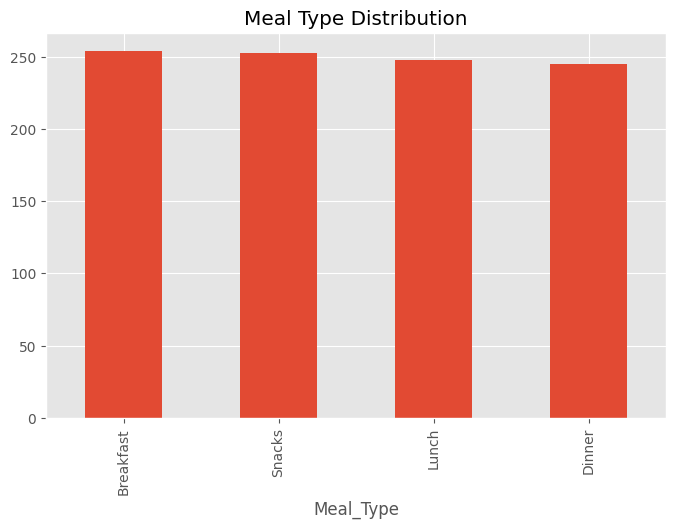

In [13]:
plt.figure( figsize=(8,5))
food['Meal_Type'].value_counts().plot(
    kind='bar'
)
plt.title("Meal Type Distribution")
plt.show()

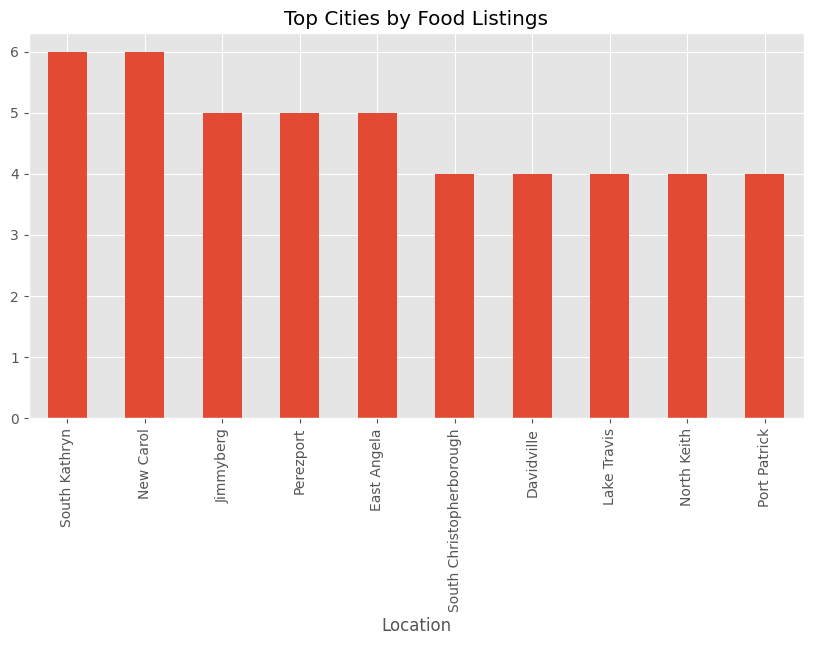

In [16]:
city_food=food.groupby(
    'Location'
).size().sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

city_food.plot(kind='bar')

plt.title("Top Cities by Food Listings")
plt.show()

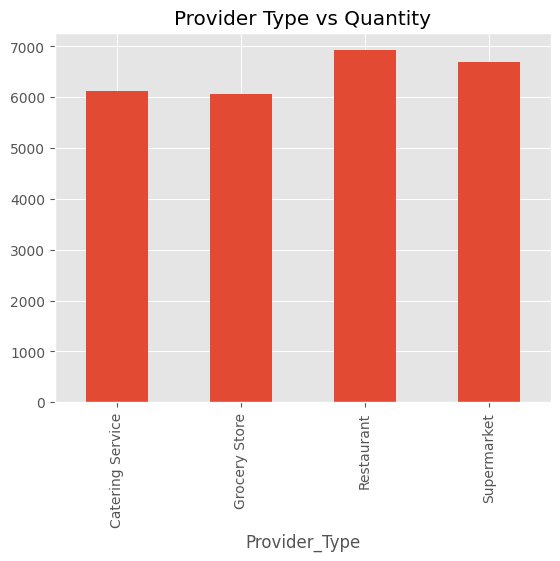

In [17]:
provider_qty=food.groupby(
    'Provider_Type'
)['Quantity'].sum()

provider_qty.plot(
    kind='bar'
)
plt.title(
    "Provider Type vs Quantity"
)
plt.show()

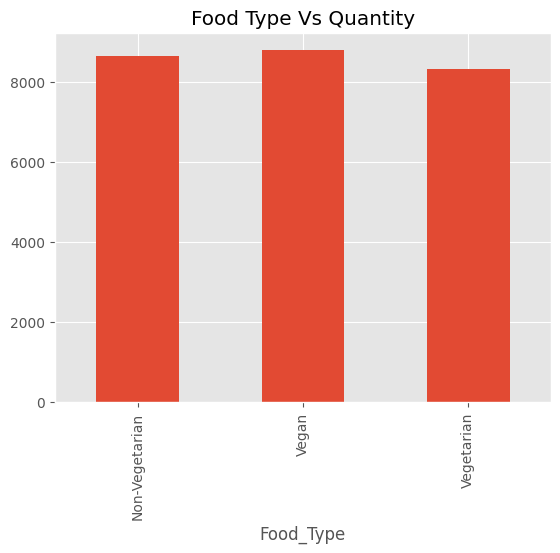

In [18]:
food.groupby(
    'Food_Type'
)['Quantity'].sum().plot(
    kind='bar'
)
plt.title(
    "Food Type Vs Quantity"
)
plt.show()

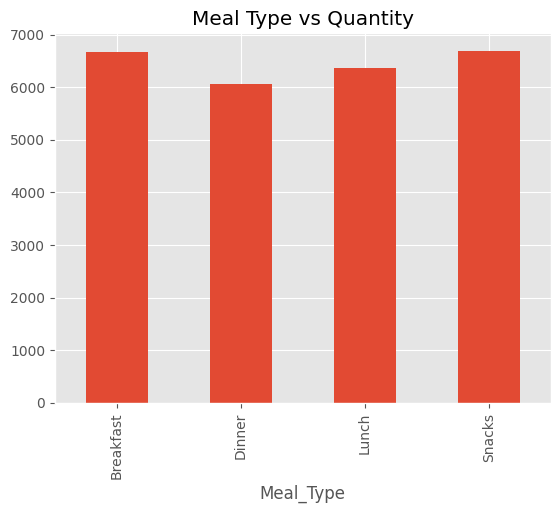

In [19]:
food.groupby(
    'Meal_Type'
)['Quantity'].sum().plot(
    kind='bar'
)

plt.title(
    "Meal Type vs Quantity"
)

plt.show()

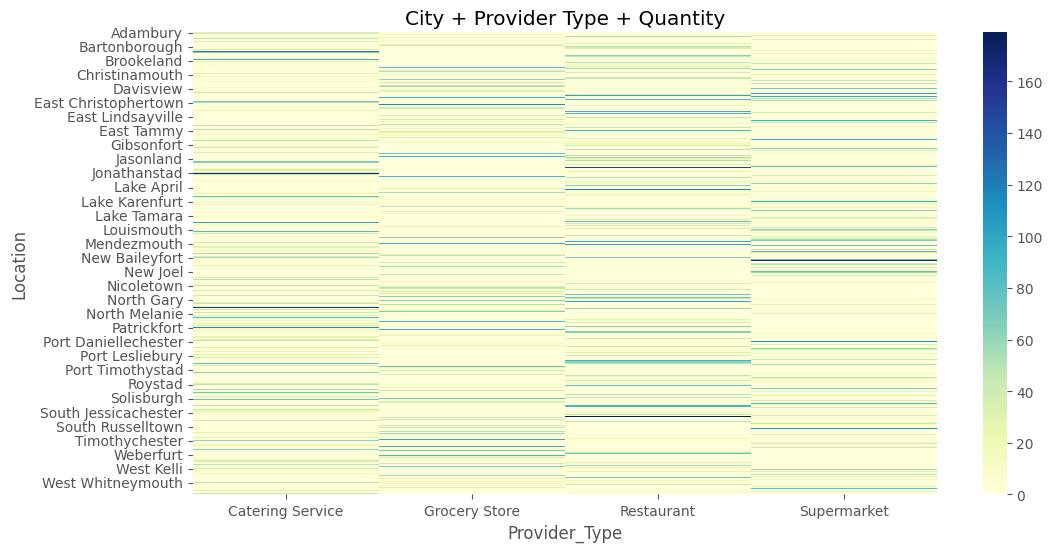

In [23]:
pivot=pd.pivot_table(
    food,
    values='Quantity',
    index='Location',
    columns='Provider_Type',
    aggfunc='sum',
    fill_value=0
)
plt.figure(figsize=(12,6))
sns.heatmap(pivot, annot=False, cmap='YlGnBu')
plt.title("City + Provider Type + Quantity")
plt.show()

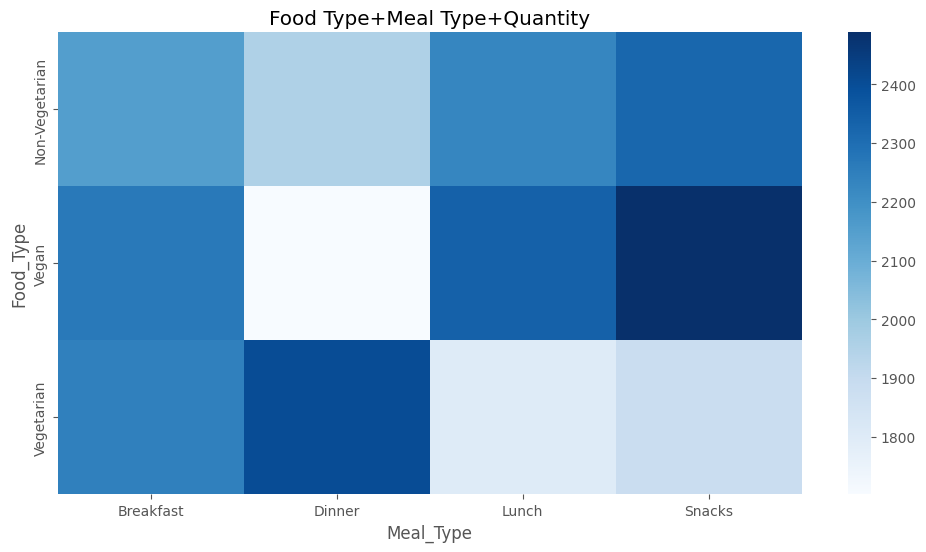

In [24]:
pivot2=pd.pivot_table(
    food,
    values='Quantity',
    index='Food_Type',
    columns='Meal_Type',
    aggfunc='sum',
    fill_value=0
)
plt.figure(figsize=(12,6))
sns.heatmap(pivot2, annot=False, cmap='Blues')
plt.title("Food Type+Meal Type+Quantity")
plt.show()

In [26]:
food_claims=food.merge(
    claims,
    on='Food_ID',
    how='inner'
)


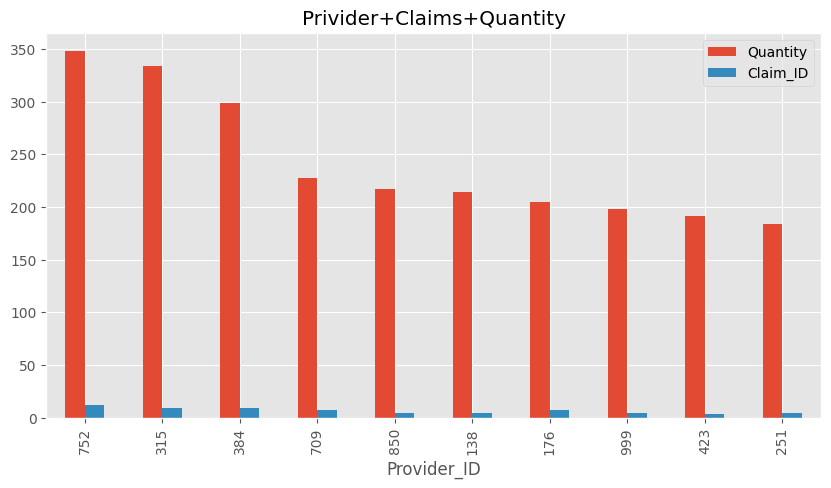

In [29]:
provider_analysis=food_claims.groupby(
    'Provider_ID'

).agg({
    'Quantity':'sum',
    'Claim_ID':'count'
}).sort_values(
    'Quantity',
    ascending=False

).head(10)
provider_analysis.plot(
    kind='bar',
    figsize=(10,5)

)
plt.title("Privider+Claims+Quantity")
plt.show()

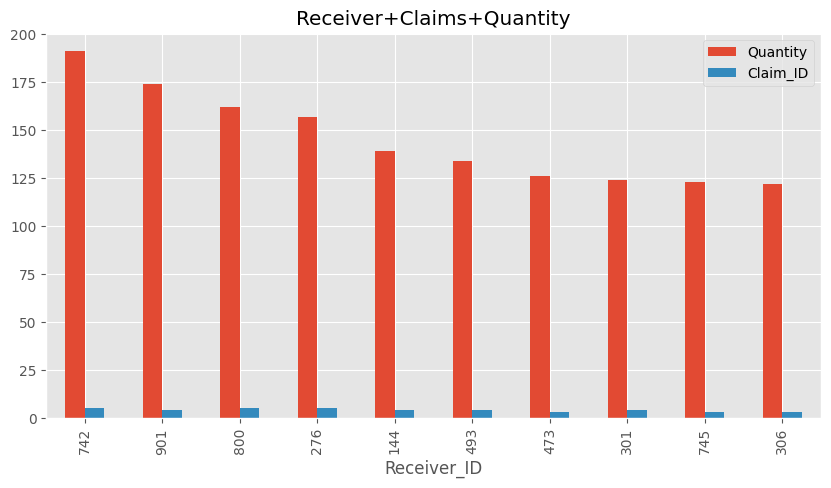

In [30]:
receiver_analysis=food_claims.groupby(
    'Receiver_ID'

).agg({
    'Quantity':'sum',
    'Claim_ID':'count'
}).sort_values(
    'Quantity',
    ascending=False

).head(10)
receiver_analysis.plot(
    kind='bar',
    figsize=(10,5)

)
plt.title("Receiver+Claims+Quantity")
plt.show()

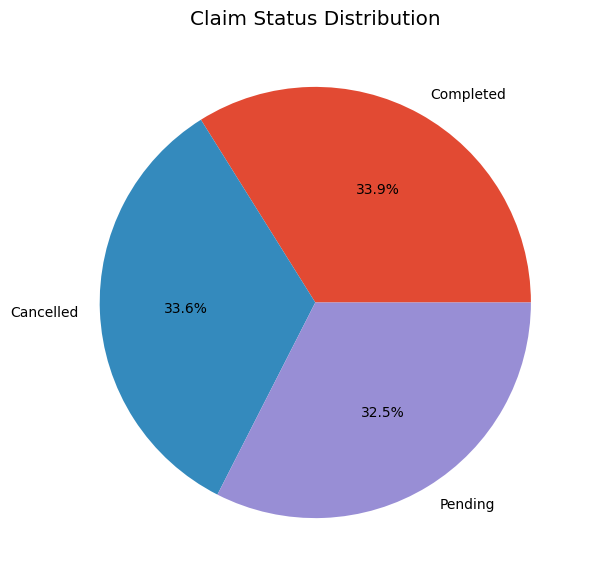

In [32]:
plt.figure(figsize=(7,7))
claims['Status'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.ylabel('')
plt.title("Claim Status Distribution")
plt.show()

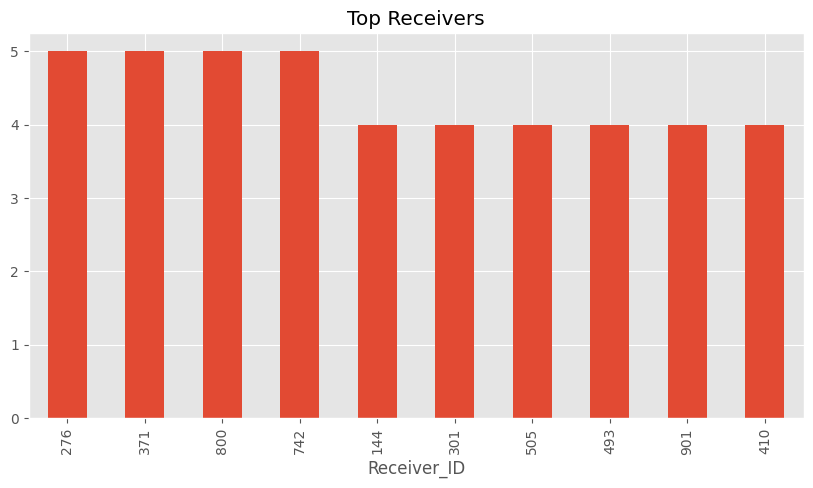

In [33]:
top_receivers=claims.groupby(
    'Receiver_ID'
).size().sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(10,5))
top_receivers.plot(
    kind='bar'
)
plt.title("Top Receivers")
plt.show()

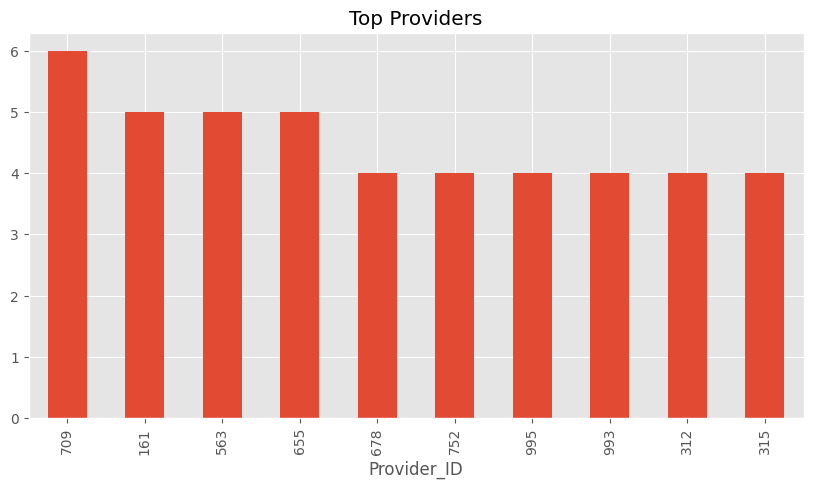

In [35]:
top_providers=food.groupby(
    'Provider_ID'
).size().sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(10,5))
top_providers.plot(
    kind='bar'
)
plt.title("Top Providers")
plt.show()